# Preparation for one locus one trait model

In [1]:
import hanoi
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

In [122]:
L = 100
n = 1
N = 100

In [123]:
M_m = np.ones((n, L))
M_v = np.ones((n, L))
M_c = np.empty((0, L))

In [124]:
M = hanoi.MutEffect(mean = M_m, var = M_v, cov = M_c)

In [125]:
M.show()

Number of traits n:
1
Number of trait pairs:
0
Number of loci L:
100
Mutation effect of mean:
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1.]]
Mutation effect of variance:
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1.]]
Mutation effect of covariance:
[]


In [126]:
M.mean.shape

(1, 100)

In [127]:
M.cov.shape

(0, 100)

In [128]:
gt = np.ones((L, N), dtype = np.float64)

In [129]:
z = np.array([[1,2], [3,4]])
z[0]

array([1, 2])

In [130]:
hanoi.sim_generation(mut_rate = 0.0, 
                      mean_0 = np.zeros((n, N)), 
                      cov_0 = np.zeros((n, n)), 
                      fit_func = "fit_neutral", 
                      genotype = gt, mut_effect=M)

In [131]:
np.array([1]).astype(np.float64)

array([1.])

In [132]:
mean_vals = np.array([0, 0.9, 1, 1.1, 2])

Make a meshgrid of $\mu_0$ and $\mu_1$

In [133]:
mean_grid = np.array(np.meshgrid(mean_vals, mean_vals)).T.reshape(-1, 2)

In [134]:
mean_grid.shape

(25, 2)

I made a meshgrid of $\sigma_0^2$ and $\sigma_1^2$

In [135]:
var_vals = np.array([10**i for i in np.arange(-3, 3, 0.1)])

In [136]:
var_grid = np.array(np.meshgrid(var_vals, var_vals)).T.reshape(-1, 2)

In [137]:
var_grid.shape

(3600, 2)

For each combination, I make a `MutEffect` object

In [138]:
mean_0 = mean_grid[0, 1]
mean_1 = mean_grid[1, 1]
var_0 = var_grid[0, 1]
var_1 = var_grid[1, 1]

In [139]:
mean_0

np.float64(0.0)

In [140]:
mean_1

np.float64(0.9)

In [141]:
var_0

np.float64(0.001)

In [142]:
var_1

np.float64(0.0012589254117941675)

In [143]:
np.zeros((math.comb(1, 2), 1))

array([], shape=(0, 1), dtype=float64)

In [144]:
np.repeat(1,10)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [145]:
np.array([np.repeat([mean_1 - mean_0],L)])

array([[0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9]])

# Testing

In [146]:
M = hanoi.MutEffect(mean = np.array([np.repeat([mean_1 - mean_0],L)]), 
                    var = np.array([np.repeat([var_1 - var_0],L)]), 
                    cov = None
                   )

In [147]:
M.show()

Number of traits n:
1
Number of trait pairs:
0
Number of loci L:
100
Mutation effect of mean:
[[0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9
  0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9
  0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9
  0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9
  0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9
  0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9]]
Mutation effect of variance:
[[0.00025893 0.00025893 0.00025893 0.00025893 0.00025893 0.00025893
  0.00025893 0.00025893 0.00025893 0.00025893 0.00025893 0.00025893
  0.00025893 0.00025893 0.00025893 0.00025893 0.00025893 0.00025893
  0.00025893 0.00025893 0.00025893 0.00025893 0.00025893 0.00025893
  0.00025893 0.00025893 0.00025893 0.00025893 0.00025893 0.00025893
  0.00025893 0.00025893 0.00025893 0.00025893 0.00025893 0.00025893
  0.00025893 0.00025893 0.00025893 0.00025893 0.0002589

I make initial genotype table

In [148]:
gt = np.ones((L, N), dtype = np.float64)

In [149]:
gt.shape

(100, 100)

In [150]:
gt

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [151]:
gt[0,0:25] = 0
gt[0,25:50] = 2

In [152]:
gt

array([[0., 0., 0., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [153]:
Counter(gt.flatten())

Counter({np.float64(1.0): 9950, np.float64(0.0): 25, np.float64(2.0): 25})

In [154]:
i = 0
j = 3500
mu_0 = np.array([mean_grid[i, 0]])
cov_0 = hanoi.cov_mtx(np.array([var_grid[j, 0]]), np.array([]))


In [155]:
mu_0

array([0.])

In [156]:
cov_0

array([[630.95734448]])

In [157]:
mean_00, mean_11 = mean_grid[i]
var_00, var_11 = var_grid[j]

M = hanoi.MutEffect(mean = np.array([np.repeat(mean_11, L)]), 
                    var = np.array([np.repeat(var_11, L)]), 
                    cov = np.empty((0, L))
                   )


In [158]:
M.mean.shape

(1, 100)

In [159]:
M.var.shape

(1, 100)

In [160]:
M.n

1

In [161]:
M.show()

Number of traits n:
1
Number of trait pairs:
0
Number of loci L:
100
Mutation effect of mean:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]]
Mutation effect of variance:
[[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]]
Mutation effect of covariance:
[]


In [162]:
A = hanoi.comp_breed_val(M, gt)

In [163]:
A.N

100

In [164]:
A.n

1

In [165]:
A.mean

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.]])

In [166]:
A.var


array([[4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95,
        4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95, 4.95,
        4.95, 4.95, 4.95, 5.05, 5.05, 5.05, 5.05, 5.05, 5.05, 5.05, 5.05,
        5.05, 5.05, 5.05, 5.05, 5.05, 5.05, 5.05, 5.05, 5.05, 5.05, 5.05,
        5.05, 5.05, 5.05, 5.05, 5.05, 5.05, 5.  , 5.  , 5.  , 5.  , 5.  ,
        5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  ,
        5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  ,
        5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  ,
        5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  , 5.  ,
        5.  ]])

In [167]:
var_00

np.float64(630.9573444802007)

In [168]:
hanoi.sim_pheno(breed_val = A, mean_0 = mean_00, cov_0 = np.array([[var_00]]))

array([[ -230.79007802, -1143.7583374 ,    18.65275504,  -934.27729478,
        -1295.9807575 ,   177.89273827,   141.49940897,   764.38413152,
         -715.04799069,  1299.13559354,  -389.58075855,  -513.46869767,
           82.2306663 ,    87.66938793,  -645.05089242,    99.86480291,
        -1131.78929517,  -518.91748949,  -170.57348934,    70.31424726,
          108.71044619,   -44.73724258,   797.08102096,  -883.04578922,
          -20.70967409,   127.3064551 ,   678.93316266,   569.26812691,
         -214.80099027, -1150.5810438 ,   400.77687642,   948.82532607,
         1232.48947949,   859.09454265,  -360.54629992,   132.44395039,
         -942.29455889,   128.68721569,   285.28516123,   589.34155036,
         -365.4501878 , -1662.86787813,  -145.35350174,   767.6837552 ,
         1197.22104494,  -361.63657643,  -355.85591806,   656.52292511,
          374.51014365,   730.23664572,   -15.05785133,   885.9163701 ,
         -697.9300267 ,  -107.29528431,  -374.65108918,  1000.36

In [107]:
gen0 = hanoi.sim_generation(mut_effect = M, 
                     genotype = gt, 
                     mean_0 = np.array([mean_00]),
                     cov_0 = np.array([[var_00]]), 
                     fit_func =  "fit_neutral",
                     mut_rate = 0.0 
                    )

In [108]:
mu_0

array([0.])

In [109]:
cov_0

array([[630.95734448]])

In [110]:
var_00

np.float64(630.9573444802007)

In [111]:
gt_next = gen0.genotype_next
gen1 = hanoi.sim_generation(mut_effect = M, 
                     genotype = gt_next, 
                     mean_0 = mu_0,
                     cov_0 = cov_0, 
                     fit_func =  "fit_neutral",
                     mut_rate = 0
                    )

In [112]:
gt.shape

(100, 100)

In [119]:
%%time
res=[]
for i in range(1):
    gens = hanoi.sim_generations(n_gen = 1000,
                                 mut_effect = M, 
                                 genotype = gt_next, 
                                 mean_0 = mu_0,
                                 cov_0 = cov_0, 
                                 fit_func =  "fit_neutral",
                                 mut_rate = 0.0001
                        )
    res.append([gens.n_gen, gens.allele_freq_last()[0]])

CPU times: user 690 ms, sys: 20 ms, total: 710 ms
Wall time: 709 ms


In [120]:
gens.allele_freq_last()

array([0.   , 1.   , 0.995, 0.005, 0.   , 1.   , 1.   , 1.   , 1.   ,
       0.5  , 1.   , 0.   , 0.   , 1.   , 0.   , 1.   , 0.4  , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 0.   , 0.84 , 1.   , 1.   ,
       1.   , 1.   , 0.   , 1.   , 1.   , 0.   , 1.   , 1.   , 0.09 ,
       1.   , 0.   , 0.   , 0.84 , 0.   , 0.465, 0.   , 0.005, 1.   ,
       0.   , 0.   , 1.   , 0.   , 0.07 , 0.965, 1.   , 0.   , 0.945,
       1.   , 1.   , 0.88 , 0.   , 1.   , 0.055, 0.99 , 1.   , 0.59 ,
       0.   , 1.   , 1.   , 0.005, 0.575, 1.   , 0.   , 1.   , 0.   ,
       0.985, 1.   , 0.   , 0.65 , 0.945, 1.   , 1.   , 1.   , 1.   ,
       0.   , 1.   , 0.98 , 0.   , 1.   , 1.   , 0.   , 1.   , 1.   ,
       0.02 , 1.   , 0.   , 1.   , 1.   , 0.07 , 0.   , 0.   , 0.075,
       0.   ])

In [57]:
np.array(res).mean(axis = 0)

array([243.31  ,   0.4302])

In [57]:
gens = hanoi.sim_generations(n_gen = 0,
                                 mut_effect = M, 
                                 genotype = gt_next, 
                                 mean_0 = mu_0,
                                 cov_0 = cov_0, 
                                 fit_func =  "fit_neutral",
                                 mut_rate = 0.001
                        )

# Testing fitness function

## fit_neutral

1D trait

In [2]:
z1 = np.arange(100, dtype = np.float64).reshape((1,-1))/100

In [3]:
z1

array([[0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99]])

In [4]:
hanoi.fit_neutral(z1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

2D trait

In [5]:
z2 = np.array([[x, y] for x in range(100) for y in range(100)], dtype = np.float64).T/100

In [6]:
z2

array([[0.  , 0.  , 0.  , ..., 0.99, 0.99, 0.99],
       [0.  , 0.01, 0.02, ..., 0.97, 0.98, 0.99]])

In [7]:
hanoi.fit_neutral(z2)

array([1., 1., 1., ..., 1., 1., 1.])

## fit_gaus

1D

In [9]:
w1 = hanoi.fit_gaus(z_opt = np.array([0], dtype = np.float64), 
                    sigma = 0.1,
                    z = z1
                   )

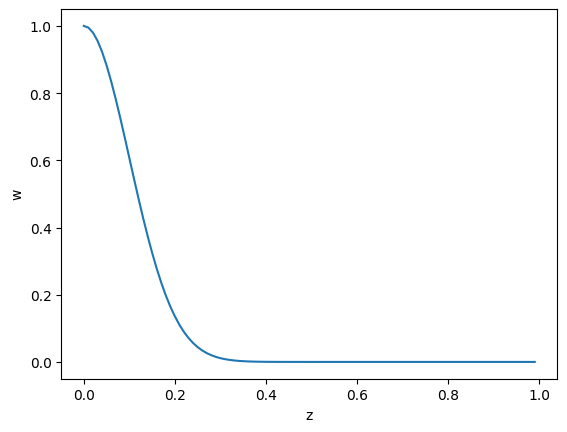

In [10]:
plt.plot(z1[0], w1)
plt.xlabel("z")
plt.ylabel("w")
plt.show()

2D trait

In [11]:
w2 = hanoi.fit_gaus(z_opt = np.array([0.25,0.5], dtype = np.float64),
               sigma = 0.5,
               z = z2
              )

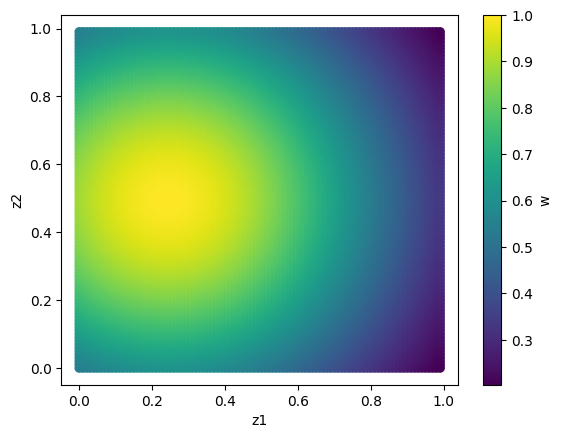

In [12]:
plt.scatter(z2[0,:], z2[1,:], c=w2, cmap='viridis')
plt.colorbar(label='w')
plt.xlabel('z1')
plt.ylabel('z2')
plt.show()


In [13]:
z2.shape

(2, 10000)

## fit_multimodal

In [17]:
z2

array([[0.  , 0.  , 0.  , ..., 0.99, 0.99, 0.99],
       [0.  , 0.01, 0.02, ..., 0.97, 0.98, 0.99]])

In [27]:
w1_m = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.2, 0.8]), 
                            z_opt = np.array([[0],[0.8]]), 
                            z = z1
                           )

In [75]:
w2_m = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.75, 0.25]), 
                            z_opt = np.array([[0,0.2],[0.8,0.7]]), 
                            z = z2
                           )

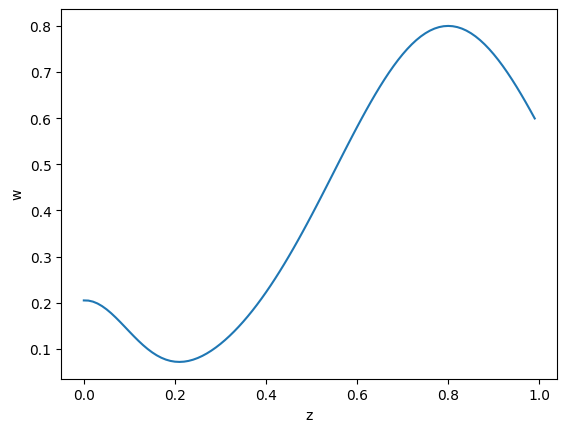

In [28]:
plt.plot(z1[0], w1_m)
plt.xlabel("z")
plt.ylabel("w")
plt.show()

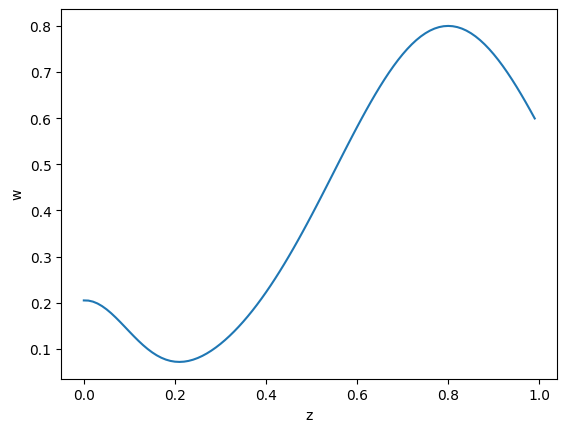

In [28]:
plt.plot(z1[0], w1_m)
plt.xlabel("z")
plt.ylabel("w")
plt.show()

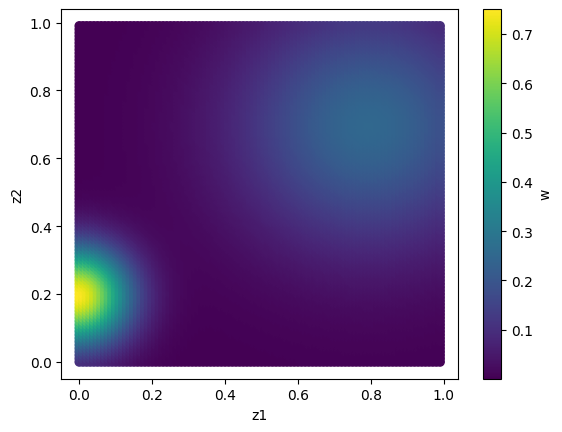

In [76]:
plt.scatter(z2[0,:], z2[1,:], c=w2_m, cmap='viridis')
plt.colorbar(label='w')
plt.xlabel('z1')
plt.ylabel('z2')
plt.show()


## fit_step

In [8]:
z2[:, None,:].shape

(2, 1, 10000)

In [16]:
boxes = np.array([[[0, 0], [0.5, 0.5]],
                  [[0.25, 0.75], [np.inf, np.inf]]]
                )

In [17]:
w2_s = hanoi.fit_step(boxes = boxes, z = z2)

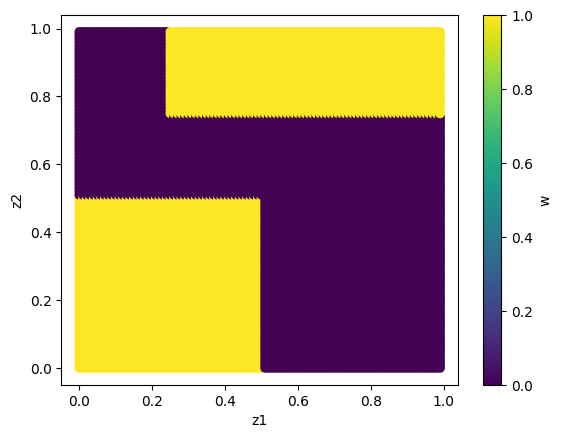

In [18]:
plt.scatter(z2[0,:], z2[1,:], c=w2_s, cmap='viridis')
plt.colorbar(label='w')
plt.xlabel('z1')
plt.ylabel('z2')
plt.show()


In [19]:
hanoi.fit_step??

Signature: hanoi.fit_step(boxes, z)
Source:   
def fit_step(boxes, z):
    """
    z:     (n, N) array of n-dimensional phenotypes of N individuals.
    boxes: (m, 2, n) array of m boxes, where boxes[i, 0, :] = lower bounds, boxes[i, 1, :] = upper bounds of i-th box. Fitness of phenotype within boxes is 1.
    Returns: (N,) array of 0 or 1
    """
    z_T = z.T
    return np.any(
        np.all((z_T[:, None, :] >= boxes[:, 0, :]) & (z_T[:, None, :] <= boxes[:, 1, :]), axis=2),
        axis=1
    ).astype(float)
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:      function

In [9]:
z = np.arange(6).reshape((2,3))
z

array([[0, 1, 2],
       [3, 4, 5]])

In [94]:
boxes

array([[[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.25, 0.75],
        [ inf,  inf]]])

In [69]:
for i in range(z.shape[1]):
    z_i = z[:,i]
    print(z_i)
    for j in range(z.shape[0]):
        if z[j, i] - boxes[] # j-th dimension of ind i's phenotype
        

[0 3]
[1 4]
[2 5]


In [95]:
boxes[0,0,:]

array([0., 0.])

In [123]:
boxes[:, 0, :].shape

(4, 2)

In [120]:
z.T[:, None, :].shape

(3, 1, 2)

In [84]:
z

array([[0, 1, 2],
       [3, 4, 5]])

In [96]:
boxes

array([[[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.25, 0.75],
        [ inf,  inf]]])

In [97]:
z.T[:, np.newaxis, :] >= boxes[:, 0, :]

array([[[ True,  True],
        [ True,  True],
        [ True,  True],
        [False,  True]],

       [[ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True]],

       [[ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True]]])

In [99]:
z.T[:, None, :]

array([[[0, 3]],

       [[1, 4]],

       [[2, 5]]])

In [118]:
z[:, None, :]

array([[[0, 1, 2]],

       [[3, 4, 5]]])

In [117]:
z[:, None, :].shape

(2, 1, 3)

In [119]:
boxes

array([[[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.  , 0.  ],
        [4.5 , 4.5 ]],

       [[0.25, 0.75],
        [ inf,  inf]]])

In [124]:
boxes.T[:, 0, :].shape

(2, 4)

In [127]:
boxes[:,0,:].T

array([[0.  , 0.  , 0.  , 0.25],
       [0.  , 0.  , 0.  , 0.75]])

In [131]:
boxes.transpose(1, 0 ,2)[:,0,:]

array([[0. , 0. ],
       [4.5, 4.5]])

In [133]:
boxes.T[0,:,:]

array([[0.  , 0.  , 0.  , 0.25],
       [4.5 , 4.5 , 4.5 ,  inf]])

In [134]:
boxes[:,0,:]

array([[0.  , 0.  ],
       [0.  , 0.  ],
       [0.  , 0.  ],
       [0.25, 0.75]])

In [139]:
boxes.transpose(1, 0, 2)[0,:,:]

array([[0.  , 0.  ],
       [0.  , 0.  ],
       [0.  , 0.  ],
       [0.25, 0.75]])

In [143]:
z[:,None,:] 

array([[[0, 1, 2]],

       [[3, 4, 5]]])

In [145]:
boxes[:,:,0]

array([[0.  , 4.5 ],
       [0.  , 4.5 ],
       [0.  , 4.5 ],
       [0.25,  inf]])

In [129]:
z[:, None, :] 

array([[[0, 1, 2]],

       [[3, 4, 5]]])

In [149]:
boxes.transpose(2,1,0)

array([[[0.  , 0.  , 0.  , 0.25],
        [4.5 , 4.5 , 4.5 ,  inf]],

       [[0.  , 0.  , 0.  , 0.75],
        [4.5 , 4.5 , 4.5 ,  inf]]])

In [150]:
z[:,:]

array([[0, 1, 2],
       [3, 4, 5]])

array([[0.  , 0.  ],
       [0.25, 0.75]])

In [77]:
np.all((z[:, None, :] >= boxes[:, 0, :]) & (z[:, None, :] <= boxes[:, 1, :]), axis=2),


ValueError: operands could not be broadcast together with shapes (2,1,3) (2,2) 

array([[[0, 1, 2]],

       [[3, 4, 5]]])

In [34]:
hanoi.fit_gaus??

Signature: hanoi.fit_gaus(sigma, z_opt, z)
Docstring: <no docstring>
Source:   
def fit_gaus(sigma, z_opt, z):
    return np.array([np.exp(-(np.linalg.norm(z[:, i] - z_opt))**2/(2 * sigma**2)) for i in range(z.shape[1])])
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:      function

In [35]:
z[:,0] - np.array([0,0])

array([1, 3])

In [300]:
np.array([np.exp(-(np.linalg.norm(z[:, i] - np.array([0,0])))**2/(2 * 1**2)) for i in range(z2.shape[1])])

array([1.        , 0.60653066, 0.13533528, ..., 0.        , 0.        ,
       0.        ])

In [154]:
res.sha

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (100, 2) + inhomogeneous part.

In [142]:
cov_0

array([[630.95734448]])

In [74]:
np.array([[1,2], 
          [3,4]]).mean(axis = 0)

array([2., 3.])

In [121]:
gen.genotype_next

array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
    

In [75]:
sim.n_gen

0

In [91]:
M_c

array([], shape=(0, 1), dtype=float64)

In [51]:
L = 1
n = 1
N = 100

In [141]:
M = hanoi.MutEffect(mean = np.array([[2]]), var = np.array([[25.118**2]]), cov = np.empty((0, L)))

In [142]:
M.show()

Number of traits n:
1
Number of trait pairs:
0
Number of loci L:
1
Mutation effect of mean:
[[2]]
Mutation effect of variance:
[[630.913924]]
Mutation effect of covariance:
[]


In [143]:
M.mean.shape

(1, 1)

In [144]:
M.cov.shape

(0, 1)

In [145]:
gt = np.ones((L, N), dtype = np.float64)

In [146]:
gt[0, 0:25] = 0
gt[0, 25:50] = 2

In [147]:
gt

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.]])

In [154]:
%%time
res = []
for i in range(100):
    sim = hanoi.sim_generations(n_gen = 0, 
                        mut_effect = M, 
                        genotype = gt, 
                        mean_0 = 0,
                        cov_0 = 0, 
                        fit_func =  "fit_step",
                        boxes = np.array([[[0.0], [np.inf]]]),
                        mut_rate = 0.0
                       )
    res.append([sim.n_gen, sim.allele_freq_last()[0]])
#print({val: int((np.array(res)[:,1] == val).sum()) for val in [0, 1, np.nan]})

        

CPU times: user 301 ms, sys: 1.96 ms, total: 303 ms
Wall time: 302 ms


In [155]:
np.array(res).mean(axis=0)

array([9.34, 0.  ])

In [26]:
%load_ext line_profiler

In [27]:
def myfunc(n):
    res = []
    for i in range(n):
        sim = hanoi.sim_generations(n_gen = 0, 
                            mut_effect = M, 
                            genotype = gt, 
                            mean_0 = mu_0,
                            cov_0 = cov_0, 
                            fit_func =  "fit_neutral",
                            mut_rate = 0
                           )
        res.append([sim.n_gen, sim.allele_freq_last()[0]])
    print({val: int((np.array(res)[:,1] == val).sum()) for val in [0, 1, np.nan]})

In [29]:
%lprun -f hanoi.sim_generations -f hanoi.sim_generation -f hanoi.comp_breed_val myfunc(10)

{0: 4, 1: 6, nan: 0}


Timer unit: 1e-09 s

Total time: 2.04598 s
File: /home/jishigohoka/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Function: sim_generation at line 140

Line #      Hits         Time  Per Hit   % Time  Line Contents
   140                                           def sim_generation(mut_effect, genotype, mut_rate, fit_func, mean_0, cov_0, **kwargs):
   141      2150     899884.0    418.6      0.0      popsize = genotype.shape[1]
   142                                               
   143                                               # Breeding value
   144      2150 1426054280.0 663281.1     69.7      A = comp_breed_val(mut_effect=mut_effect, genotype=genotype)
   145                                               
   146                                               # Phenotype
   147                                               #z = sim_pheno(breed_val=A, mean_0=mean_0, cov_0 = cov_0)
   148      2150   44369262.0  20636.9      2.2      z = sim_pheno_c(breed_val=A, mean_0

In [33]:
M.mean.shape

(1, 100)

In [28]:
%%time
res = []
for i in range(10):
    sim = hanoi.sim_generations_c(n_gen = 0, 
                        mut_effect = M, 
                        genotype = gt, 
                        mean_0 = mu_0,
                        cov_0 = cov_0, 
                        fit_func =  "fit_neutral",
                        boxes = np.array([[[1], [math.inf]]]) ,
                        mut_rate = 0
                       )
    res.append([sim.n_gen, sim.allele_freq_last()[0]])
print({val: int((np.array(res)[:,1] == val).sum()) for val in [0, 1, np.nan]})

        

AttributeError: module 'hanoi' has no attribute 'sim_generations_c'

In [ ]:
hanoi.sim_

In [26]:
np.any(np.array([1,0]) == 0)

np.True_

In [28]:
gt[0,0]

np.int64(2)

In [28]:
M.cov

array([], shape=(0, 100), dtype=float64)

In [29]:
gt.shape

(100, 100)

In [30]:
hanoi.sim_pheno??

Signature: hanoi.sim_pheno(breed_val: hanoi.hanoi.BreedVal, mean_0, cov_0)
Docstring: <no docstring>
Source:   
def sim_pheno(breed_val: BreedVal, mean_0, cov_0):
    # Cholesky decomposition of the covariance matrices
    chol = jnp.linalg.cholesky(cov_0 + breed_val.varcov)
    # Standard normal sampling
    z_std = np.random.standard_normal((breed_val.N, breed_val.n))
    # Convert N vectors of n standard normal variables to the N phenotype values in n dimensions
    z = np.einsum('ijk,ik->ij', chol, z_std) + mean_0
    return z
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:      function

In [31]:
res

[[88, np.float64(1.0)],
 [99, np.float64(0.0)],
 [163, np.float64(0.0)],
 [529, np.float64(0.0)],
 [73, np.float64(1.0)],
 [447, np.float64(1.0)],
 [69, np.float64(0.0)],
 [337, np.float64(1.0)],
 [301, np.float64(0.0)],
 [168, np.float64(1.0)]]

In [29]:
gt

array([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [30]:
mu_0

array([0.])

In [31]:
cov_0**0.5


array([[25.11886432]])

In [63]:
%load_ext line_profiler

In [64]:
%lprun -f hanoi.sim_generations hanoi.sim_generations(n_gen = 0, mut_effect = M, genotype = gt, mean_0 = mu_0, cov_0 = cov_0, fit_func =  "fit_step", boxes = np.array([[[1], [math.inf]]]) , mut_rate = 0 )

Timer unit: 1e-09 s

Total time: 0.230454 s
File: /home/jishigohoka/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Function: sim_generations at line 173

Line #      Hits         Time  Per Hit   % Time  Line Contents
   173                                           def sim_generations(n_gen, mut_effect, genotype, mut_rate, fit_func, mean_0, cov_0, **kwargs):
   174         1        687.0    687.0      0.0      generations_list = []
   175         1        291.0    291.0      0.0      genotype_cur = genotype
   176         1        355.0    355.0      0.0      if n_gen == 0:
   177         1        228.0    228.0      0.0          i = 0
   178       156   16054024.0 102910.4      7.0          while not (np.all(np.isin(genotype_cur, [0,2])) or np.all(np.isnan(genotype_cur))):
   179       310     138966.0    448.3      0.1              generations_list.append(
   180       465  209729568.0 451031.3     91.0                      sim_generation(mut_effect = mut_effect, 
   181 

In [135]:
%lprun -f hanoi.sim_generation hanoi.sim_generation(mut_effect=M, cov_0 = cov_0, fit_func = "fit_neutral", genotype= gt, mean_0=mu_0, mut_rate=0, boxes = np.array([[[1], [math.inf]]]) ,)

Timer unit: 1e-09 s

Total time: 0.00523523 s
File: /home/jishigohoka/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Function: sim_generation at line 138

Line #      Hits         Time  Per Hit   % Time  Line Contents
   138                                           def sim_generation(mut_effect, genotype, mut_rate, fit_func, mean_0, cov_0, **kwargs):
   139         1       2544.0   2544.0      0.0      popsize = genotype.shape[1]
   140                                               
   141                                               # Breeding value
   142         1    1499090.0  1.5e+06     28.6      A = comp_breed_val(mut_effect=mut_effect, genotype=genotype)
   143                                               
   144                                               # Phenotype
   145         1    2785866.0 2.79e+06     53.2      z = sim_pheno(breed_val=A, mean_0=mean_0, cov_0 = cov_0)
   146                                               
   147                          

In [106]:
%lprun -f hanoi.sim_reproduction hanoi.sim_reproduction(popsize = 100, genotype = np.ones((100, 100)), fitness = np.tile([0,1],50))


Timer unit: 1e-09 s

Total time: 0.00179956 s
File: /home/jishigohoka/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Function: sim_reproduction at line 258

Line #      Hits         Time  Per Hit   % Time  Line Contents
   258                                           def sim_reproduction(popsize, genotype, fitness ):
   259                                               # number of offspring per genotype of each genotype
   260         1       1016.0   1016.0      0.1      n_loci = genotype.shape[0]
   261         1      22421.0  22421.0      1.2      if fitness.sum() == 0:
   262                                                   genotype_next = np.full((n_loci, popsize), np.nan)
   263                                                   n_offspring = np.zeros(popsize, dtype = int)
   264                                                   #raise RuntimeError("Fitness of all individuals is 0")
   265                                                   return genotype_next, n_offs

In [39]:
np.tile([0,1],50)

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

In [ ]:
(0, 1)

In [33]:
%lprun -f hanoi.sim_reproduction hanoi.sim_reproduction(popsize=N, fitness=np.ones(N), genotype=gt)

Timer unit: 1e-09 s

Total time: 0.00819145 s
File: /home/jishigohoka/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Function: sim_reproduction at line 258

Line #      Hits         Time  Per Hit   % Time  Line Contents
   258                                           def sim_reproduction(popsize, genotype, fitness ):
   259                                               # number of offspring per genotype of each genotype
   260         1      30906.0  30906.0      0.4      if fitness.sum() == 0:
   261                                                   n_loci = genotype.shape[0]
   262                                                   genotype_next = np.full((n_loci, popsize), np.nan)
   263                                                   n_offspring = np.zeros(popsize, dtype = int)
   264                                                   #raise RuntimeError("Fitness of all individuals is 0")
   265                                                   return genotype_next, n_

In [347]:
popsize = 4
n_loci = 3
fitness = np.random.uniform(0, 1, size = popsize)
genotype = np.random.randint(0, 3, (n_loci, popsize))

In [348]:
genotype

array([[1, 2, 1, 0],
       [2, 0, 2, 2],
       [1, 2, 0, 0]])

In [442]:
n_offspring = np.random.multinomial(n = 2 * popsize, pvals = fitness/fitness.sum())

# index of 2N parents
sam = np.repeat(range(popsize), n_offspring)
np.random.shuffle(sam)

In [443]:
sam.size

8

In [444]:
# Make genotype of next parents randomly take one haplotype per locus per parent
genotype_next_T = np.array([np.sum(np.random.binomial(1, genotype[:, sam[[2 * i, 2 * i + 1]]]/2), axis = 0) for i in range(popsize)])

In [445]:
sam[[2 * 0, 2 * 0 + 1]]

array([2, 2])

In [446]:
sam

array([2, 2, 1, 2, 2, 2, 2, 2])

In [460]:
genotype[:, sam]

array([[1, 1, 2, 1, 1, 1, 1, 1],
       [2, 2, 0, 2, 2, 2, 2, 2],
       [0, 0, 2, 0, 0, 0, 0, 0]])

In [523]:
np.random.binomial(1, genotype.T[sam,:]/2 ).reshape(popsize, 2, n_loci).sum(axis = 1).T

array([[1, 2, 0, 0],
       [2, 1, 2, 2],
       [0, 1, 0, 0]])

In [441]:
np.random.binomial(1, genotype[sam, :]/2).reshape(-1, )

array([[1, 1, 0, 0],
       [0, 1, 0, 0],
       [1, 0, 1, 1],
       [1, 1, 0, 0],
       [1, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [1, 0, 1, 1]])

In [408]:
np.random.binomial(1, genotype[:, sam]/2).T.reshape(popsize, 2, n_loci).sum(axis = 1)

array([[0, 2, 0],
       [1, 1, 1],
       [1, 2, 0],
       [1, 1, 1]])

In [84]:
np.sum(np.random.binomial(1, genotype[sam[[2 * 0, 2 * 0 + 1]]]/2), axis = 0)

array([1, 0, 1, 2, 1, 1, 0, 0, 2, 0])

In [59]:
np.random.binomial(1, genotype[sam[[2 * 0, 2 * 0 + 1]]]/2)

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 0, 1, 0]])

In [42]:
genotype_next_T.T, n_offspring

(array([[1, 2, 1, 0, 1, 2, 1, 0, 2, 1],
        [2, 0, 1, 2, 1, 1, 0, 1, 1, 1],
        [0, 1, 2, 0, 0, 1, 2, 2, 1, 1],
        [1, 1, 2, 0, 1, 1, 1, 2, 0, 2],
        [0, 1, 2, 2, 1, 1, 0, 2, 2, 1],
        [1, 0, 1, 1, 0, 1, 0, 2, 1, 2],
        [1, 0, 2, 1, 1, 0, 0, 2, 1, 0],
        [1, 1, 2, 1, 1, 1, 2, 0, 2, 1],
        [2, 0, 0, 1, 1, 2, 2, 2, 1, 1],
        [0, 1, 2, 2, 1, 0, 0, 0, 2, 2]]),
 array([0, 2, 2, 0, 1, 4, 0, 1, 6, 4]))

In [134]:
cov_0

array([[630.95734448]])

In [129]:
cov_0

array([[630.95734448]])

In [135]:
mu_0

array([0.])

In [136]:
mu_1

np.float64(0.0)

In [130]:
res = []
for i in range(10):
    sim = hanoi.sim_generations(n_gen = 0, 
                          mut_effect = M, 
                          genotype = gt, 
                          mean_0 = mu_0,
                          cov_0 = cov_0, 
                          fit_func =  "fit_step",
                          boxes = np.array([[[1], [math.inf]]]) ,
                          mut_rate = 0
                         )
    res.append([sim.n_gen, sim.allele_freq_last()[0]])

In [131]:
np.array(res)

array([[282.,   1.],
       [ 61.,   1.],
       [ 71.,   0.],
       [156.,   0.],
       [ 62.,   1.],
       [111.,   0.],
       [131.,   1.],
       [194.,   0.],
       [360.,   1.],
       [170.,   1.]])

In [111]:
sim.allele_freqs()

array([[0.5]])

In [55]:
np.array([[[1], [math.inf]]]) 

array([[[ 1.],
        [inf]]])

In [37]:
sigma2_grid[0, 0]

np.float64(0.001)

In [47]:
hanoi.cov_mtx(np.array([sigma2_grid[0,0]]), np.array([]))

array([[0.001]])

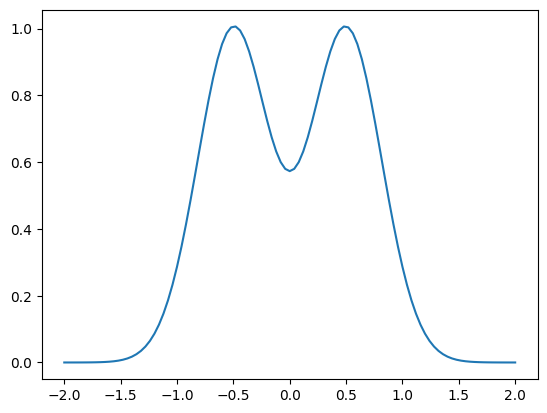

In [34]:
z = np.linspace(-2, 2, 101)

w = hanoi.fit_multimodal(sigma=np.sqrt(np.array([0.1,0.1])), p = np.array([1,1]), z_opt = np.array([-0.5, 0.5]), z = z)

plt.plot(z, w)
plt.show()

In [35]:
?hanoi.fit_multimodal

Signature: hanoi.fit_multimodal(sigma, p, z_opt, z)
Docstring:
Computes fitness based on a multimodal fitness function.

Arguments:
    sigma:  (n_peaks,) array specifying SD of n_peak peaks
    p:      (n_peaks,) array specifying relative height of peaks
    z_opt:  (n_peaks, n) array specifying the coordinate of n_peak peaks in the n-dimensional phenotype space
    z:      (N, n) array representing n-dimensional phenotypes of N individuals.
Returns: (N,) array representing fitness of N individuals
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function

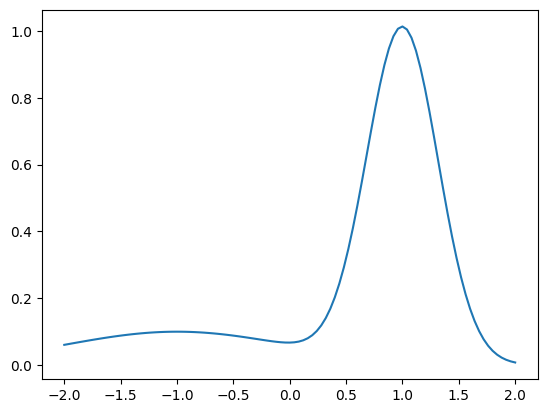

In [14]:
z = np.linspace(-2, 2, 101)

w = hanoi.fit_multimodal(sigma=np.sqrt(np.array([1,0.1])), p = np.array([0.1,1]), z_opt = np.array([-1, 1]), z = z)

plt.plot(z, w)
plt.show()